In [ ]:
import numpy as np
import pandas as pd
import os
import random
import time
import gc

In [5]:
def maximum_error(A,B):
  n = len(A)
  return max([np.abs(A[i] - B[i]) for i in range(n)])

In [6]:
def incremental_criteria(x, x_next, rho):
  return np.linalg.norm(x_next - x) <= rho

def residual_criteria(A: np.ndarray, b: np.ndarray, x_next: np.ndarray, rho):
  return np.linalg.norm(A @ x_next - b) <= rho

In [7]:
def jakobi(A: np.ndarray, b: np.ndarray, rho, x, stop_condition='residual', max_iter=10000):
  D = np.diag(np.diag(A))
  R = A - D
  inv = D / np.power(D[0,0],2) # diagonal matrix inversion, knowing that all the elements on diagonal are equal to k=11
  for i in range(1, max_iter+1):
    x_next = inv @ (b - R @ x)
    if( stop_condition == 'residual' and residual_criteria(A, b, x_next, rho) ):
      return i, x_next
    elif( stop_condition == 'incremental' and incremental_criteria(x, x_next, rho) ):
      return i, x_next

    x = x_next
  
  return i, x_next

In [8]:
def get_time(func, *args, **kwargs):
  gc.collect()
  start_time = time.perf_counter()
  func(*args, **kwargs)
  end_time = time.perf_counter()
  total_time = end_time - start_time
  return total_time

Generowanie macierzy 

In [9]:
def get_X_vector(n, precision=np.float64):
  random.seed(42)
  X = np.array([1 if random.randint(1,2) == 1 else -1 for _ in range(n)], dtype=precision)
  return X

k, m = 11, 3

def element_function(i, j, n):
  if(i == j):
    return k
  return 1/(np.abs(i-j) + m)

def task_matrix(n, X, precision=np.float64):
  A = np.array([[element_function(i,j,n) for j in range(n)] for i in range(n)], dtype=precision)
  b = A @ X
  return A, b 

def initial_x(A: np.ndarray):
  n = A.shape[0]
  X = np.array([0] * n)

N = 3
PRECISION = np.float64

X = get_X_vector(N, PRECISION)

A, b = (task_matrix(N, X, PRECISION))
print(A)
result = jakobi(A, b, 0.000000001, X)
print(X)
print(result)

[[11.    0.25  0.2 ]
 [ 0.25 11.    0.25]
 [ 0.2   0.25 11.  ]]
[ 1.  1. -1.]
(1, array([ 1.,  1., -1.]))


In [10]:
def spectral_radius(A: np.ndarray) -> np.ndarray:
  return np.max(np.abs(np.linalg.eigvals(A)))

In [11]:
RHO = [10**k for k in [-2, -3, -4, -5, -7, -10, -15]]
N_SIZES = [3, 5, 10, 15, 20, 50, 100, 200, 500, 750, 1000] 


MAX_ITERATIONS = 10000
OUTPUT_DIR = "data"
X0_TYPES = {
    "zero": lambda n: np.zeros(n),
    "fifty": lambda n: np.full(n, 50.0),
    "hundred": lambda n: np.full(n, 100.0),
}

os.makedirs(OUTPUT_DIR, exist_ok=True)


def run_single_experiment(args):
    stop_condition, x0_type, n, rho = args
    x_true = get_X_vector(n)
    A, b = task_matrix(n, x_true)
    x0 = X0_TYPES[x0_type](n)
    
    start = time.perf_counter()
    iters, x_approx = jakobi(A, b, rho, x0, stop_condition=stop_condition, max_iter=MAX_ITERATIONS)
    total_time = time.perf_counter() - start
    avg_time = total_time / iters if iters > 0 else np.nan
    error = maximum_error(x_true, x_approx)
        
    return {
        "stop_condition": stop_condition,
        "x0_type": x0_type,
        "n": n,
        "rho": rho,
        "iterations": iters,
        "avg_time": avg_time,
        "error": error,
    }

def run():
    tasks = []
    for stop_condition in ["incremental", "residual"]:
        for x0_type in X0_TYPES:
            for n in N_SIZES:
                for rho in RHO:
                    tasks.append((stop_condition, x0_type, n, rho))

    results = [run_single_experiment(task) for task in tasks]

    pd.set_option('display.float_format', '{:.4e}'.format)
    df_all = pd.DataFrame(results)
    
    for stop_condition in ["incremental", "residual"]:
        df_sub = df_all[df_all["stop_condition"] == stop_condition]
        for metric in ["error", "iterations", "avg_time"]:
            df_sub[["rho", "n", "x0_type", metric]].to_csv(
                os.path.join(OUTPUT_DIR, f"heatmap_{stop_condition}_{metric}.csv"),
                index=False,
                float_format='%.5e'
            )

run()

In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

plt.style.use("default")
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#e5e5e5'
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

input_dir = "data"
output_dir = "heatmaps_jakobi"
os.makedirs(output_dir, exist_ok=True)

metrics = ["error", "iterations", "avg_time"]
metrics_names = ["Błąd bezwzględny", "Liczba iteracji", "Średni czas na iterację [s]"]
stop_conditions = ["incremental", "residual"]
stop_conditions_names = ["Kryterium przyrostowe", "Kryterium rezydualne"]
x0_types = ["zero", "fifty", "hundred"]
x0_names = {"zero": r"$[0]^{n \times 1}$", "fifty": r"$[50]^{n \times 1}$", "hundred": r"$[100]^{n \times 1}$"}

def plot_heatmap(df, x_col, y_col, x_col_name, y_col_name, value_col, value_col_name, title, filename, metric_type):
  pivot = df.pivot_table(index=y_col, columns=x_col, values=value_col)
  pivot = pivot[sorted(pivot.columns, reverse=True)]
  pivot = pivot.sort_index()

  fig, ax = plt.subplots(figsize=(10, max(4, len(pivot) * 0.5)))

  vmin = pivot.min().min()
  vmax = pivot.max().max()

  # Decide on using log scale if data is all positive and spans multiple orders of magnitude
  use_log = vmin > 0 and vmax / vmin > 1000 or metric_type == 'iterations' or metric_type == 'error'

  if use_log:
    norm = LogNorm(vmin=max(vmin, 1e-10), vmax=vmax)
    fmt = "{val:.2e}" if metric_type != 'iterations' else "{val:.0f}"
  else:
    norm = None
    if vmax - vmin < 1:
      fmt = "{val:.2f}"
    elif vmax < 1000:
      fmt = "{val:.1f}"
    else:
      fmt = "{val:.0f}"

  # Turn off grid for the heatmap image display itself, as grid lines through cells look bad
  ax.grid(False)

  im = ax.imshow(pivot.values, cmap="viridis_r", norm=norm, aspect='auto')
  
  cbar = fig.colorbar(im, ax=ax)
  cbar.set_label(value_col_name)
  
  # Show all ticks and label them with the respective list entries
  ax.set_xticks(np.arange(len(pivot.columns)))
  ax.set_yticks(np.arange(len(pivot.index)))
  
  ax.set_xticklabels([f"{tick:.0e}" for tick in pivot.columns], rotation=45, ha='right')
  ax.set_yticklabels(pivot.index)

  # Loop over data dimensions and create text annotations
  for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
      val = pivot.values[i, j]
      if np.isnan(val):
        text_val = "NaN"
      else:
        text_val = fmt.format(val=val)
      
      # Determine text color based on background intensity
      if norm is not None:
        normalized_val = norm(val) if not np.isnan(val) else 0.5
      else:
        normalized_val = (val - vmin) / (vmax - vmin) if (vmax - vmin) > 0 and not np.isnan(val) else 0.5
      
      # For viridis_r: 0 is yellow (light), 1 is purple/blue (dark).
      # Threshold at 0.45 to decide text color (dark text on light, light text on dark)
      color = "w" if normalized_val > 0.45 else "k"
      ax.text(j, i, text_val, ha="center", va="center", color=color, fontsize=9)

  ax.set_title(title, pad=15)
  ax.set_xlabel(x_col_name)
  ax.set_ylabel(y_col_name)
  
  fig.tight_layout()
  plt.savefig(filename, dpi=300, bbox_inches='tight')
  plt.close(fig)
  print(f"Zapisano: {filename}")

for stop_i, stop in enumerate(stop_conditions):
  for metric_i, metric in enumerate(metrics):
    file_path = os.path.join(input_dir, f"heatmap_{stop}_{metric}.csv")
    if not os.path.exists(file_path):
      print(f"Brakuje pliku: {file_path}")
      continue

    df = pd.read_csv(file_path)

    for x0 in x0_types:
      df_sub = df[df["x0_type"] == x0]

      plot_heatmap(
        df_sub,
        x_col="rho",
        y_col="n",
        x_col_name="Dokładność ρ",
        y_col_name="Rozmiar układu N",
        value_col=metric,
        value_col_name=metrics_names[metric_i],
        title=f"{stop_conditions_names[stop_i]} - {metrics_names[metric_i]} \n $x^{{(0)}}$ = {x0_names[x0]}",
        filename=os.path.join(output_dir, f"{stop}_{metric}_{x0}.png"),
        metric_type=metric
      )

Zapisano: heatmaps_jakobi\incremental_error_zero.png
Zapisano: heatmaps_jakobi\incremental_error_fifty.png
Zapisano: heatmaps_jakobi\incremental_error_hundred.png
Zapisano: heatmaps_jakobi\incremental_iterations_zero.png
Zapisano: heatmaps_jakobi\incremental_iterations_fifty.png
Zapisano: heatmaps_jakobi\incremental_iterations_hundred.png
Zapisano: heatmaps_jakobi\incremental_avg_time_zero.png
Zapisano: heatmaps_jakobi\incremental_avg_time_fifty.png
Zapisano: heatmaps_jakobi\incremental_avg_time_hundred.png
Zapisano: heatmaps_jakobi\residual_error_zero.png
Zapisano: heatmaps_jakobi\residual_error_fifty.png
Zapisano: heatmaps_jakobi\residual_error_hundred.png
Zapisano: heatmaps_jakobi\residual_iterations_zero.png
Zapisano: heatmaps_jakobi\residual_iterations_fifty.png
Zapisano: heatmaps_jakobi\residual_iterations_hundred.png
Zapisano: heatmaps_jakobi\residual_avg_time_zero.png
Zapisano: heatmaps_jakobi\residual_avg_time_fifty.png
Zapisano: heatmaps_jakobi\residual_avg_time_hundred.png


In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

# Setup style (clean whitegrid alternative to seaborn)
plt.style.use("default")
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#e5e5e5'
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['grid.alpha'] = 1.0
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'

input_dir = "data"
output_dir = "comparison_plots"
os.makedirs(output_dir, exist_ok=True)

# Configuration
metrics = ["error", "iterations", "avg_time"]
metrics_names = ["Błąd bezwzględny", "Liczba iteracji", "Średni czas na iterację [s]"]
stop_conditions = ["incremental", "residual"]
stop_conditions_names = {"incremental": "Kryterium przyrostowe", "residual": "Kryterium rezydualne"}
x0_types = ["zero", "fifty", "hundred"]
x0_names = {"zero": r"$x^{(0)} = [0]^{n}$", "fifty": r"$x^{(0)} = [50]^{n}$", "hundred": r"$x^{(0)} = [100]^{n}$"}

# Colors for different combinations
colors = {
    ("incremental", "zero"): "#1f77b4",
    ("incremental", "fifty"): "#ff7f0e", 
    ("incremental", "hundred"): "#2ca02c",
    ("residual", "zero"): "#d62728",
    ("residual", "fifty"): "#9467bd",
    ("residual", "hundred"): "#8c564b"
}

def create_metric_comparison_plots():
    """
    Create metric comparison plots with each N value in a separate file.
    Each file shows one metric comparing all stop criteria and starting vectors.
    """
    
    # Load all data
    all_data = []
    for stop in stop_conditions:
        for metric in metrics:
            file_path = os.path.join(input_dir, f"heatmap_{stop}_{metric}.csv")
            if os.path.exists(file_path):
                df = pd.read_csv(file_path)
                df['stop_condition'] = stop
                df['metric'] = metric
                all_data.append(df)
    
    if not all_data:
        print("Brak danych do wczytania. Upewnij się, że pliki CSV istnieją w katalogu 'data'.")
        return
    
    # Combine all data
    combined_df = pd.concat(all_data, ignore_index=True)
    
    # Create pivot table for easier plotting
    plot_data = []
    for _, row in combined_df.iterrows():
        plot_data.append({
            'stop_condition': row['stop_condition'],
            'x0_type': row['x0_type'],
            'n': row['n'],
            'rho': row['rho'],
            'metric_type': row['metric'],
            'value': row[row['metric']]
        })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Get all unique N values
    n_values = sorted(plot_df['n'].unique())
    
    # Create plots for each metric and each N value
    for metric_idx, metric in enumerate(metrics):
        metric_data = plot_df[plot_df['metric_type'] == metric]
        
        for n in n_values:
            n_data = metric_data[metric_data['n'] == n]
            
            if n_data.empty:
                continue
            
            # Create figure for this specific metric and N
            plt.figure(figsize=(12, 8))
            
            # Plot each combination of stop criteria and starting vector
            for stop in stop_conditions:
                for x0 in x0_types:
                    subset = n_data[(n_data['stop_condition'] == stop) & (n_data['x0_type'] == x0)].sort_values('rho')
                    
                    if not subset.empty:
                        color = colors[(stop, x0)]
                        label = f"{stop_conditions_names[stop]}, {x0_names[x0]}"
                        
                        plt.plot(subset['rho'], subset['value'], 
                               marker='o', color=color, linewidth=2.5, markersize=8,
                               label=label, alpha=0.8)
            
            plt.xscale('log')
            if metric == 'error' or metric == 'avg_time':
                plt.yscale('log')
            elif metric == 'iterations':
                plt.ylim(top=100, bottom=0)  # Cap iterations plot at 100 as per user configuration
            
            # Set x-axis ticks to show only tested rho values
            tested_rho_values = [10**(-k) for k in [2, 3, 4, 5, 7, 10, 15]]
            actual_rho_values = sorted(n_data['rho'].unique())
            
            plt.xticks(actual_rho_values, [f'$10^{{-{int(-np.log10(rho))}}}$' for rho in actual_rho_values])
            
            plt.xlabel('Dokładność ρ', fontsize=12)
            plt.ylabel(metrics_names[metric_idx], fontsize=12)
            plt.title(f'{metrics_names[metric_idx]} - N = {n}', fontsize=14, fontweight='bold')
            plt.legend(fontsize=10, loc='best')
            
            # Improve layout
            plt.tight_layout()
            
            # Save the plot
            filename = f'metric_comparison_{metric}_N{n}.png'
            plt.savefig(os.path.join(output_dir, filename), dpi=300, bbox_inches='tight')
            plt.close()
            print(f"Zapisano: {filename}")
    
    print(f"\nWygenerowano wszystkie wykresy porównawcze!")
    print(f"Liczba wykresów: {len(metrics)} metryk × {len(n_values)} rozmiarów N = {len(metrics) * len(n_values)} plików")

# Run the plotting function
create_metric_comparison_plots()

Zapisano: metric_comparison_error_N3.png
Zapisano: metric_comparison_error_N5.png
Zapisano: metric_comparison_error_N10.png
Zapisano: metric_comparison_error_N15.png
Zapisano: metric_comparison_error_N20.png
Zapisano: metric_comparison_error_N50.png
Zapisano: metric_comparison_error_N100.png
Zapisano: metric_comparison_error_N200.png
Zapisano: metric_comparison_error_N500.png
Zapisano: metric_comparison_error_N750.png
Zapisano: metric_comparison_error_N1000.png
Zapisano: metric_comparison_iterations_N3.png
Zapisano: metric_comparison_iterations_N5.png
Zapisano: metric_comparison_iterations_N10.png
Zapisano: metric_comparison_iterations_N15.png
Zapisano: metric_comparison_iterations_N20.png
Zapisano: metric_comparison_iterations_N50.png
Zapisano: metric_comparison_iterations_N100.png
Zapisano: metric_comparison_iterations_N200.png
Zapisano: metric_comparison_iterations_N500.png
Zapisano: metric_comparison_iterations_N750.png
Zapisano: metric_comparison_iterations_N1000.png
Zapisano: met

In [ ]:
spectral_radius_data = []
for n in N_SIZES:
    x_dummy = get_X_vector(n)
    A, _ = task_matrix(n, x_dummy)
    D = np.diag(np.diag(A))
    R = A - D
    inv = D / np.power(D[0,0], 2)
    T = -inv @ R
    rho = spectral_radius(T)
    spectral_radius_data.append({
        'n': n,
        'spectral_radius': rho
    })

df_sr = pd.DataFrame(spectral_radius_data)
df_sr.to_csv('data/spectral_radius_results.csv', index=False)
print("Saved spectral_radius_results.csv to data/")

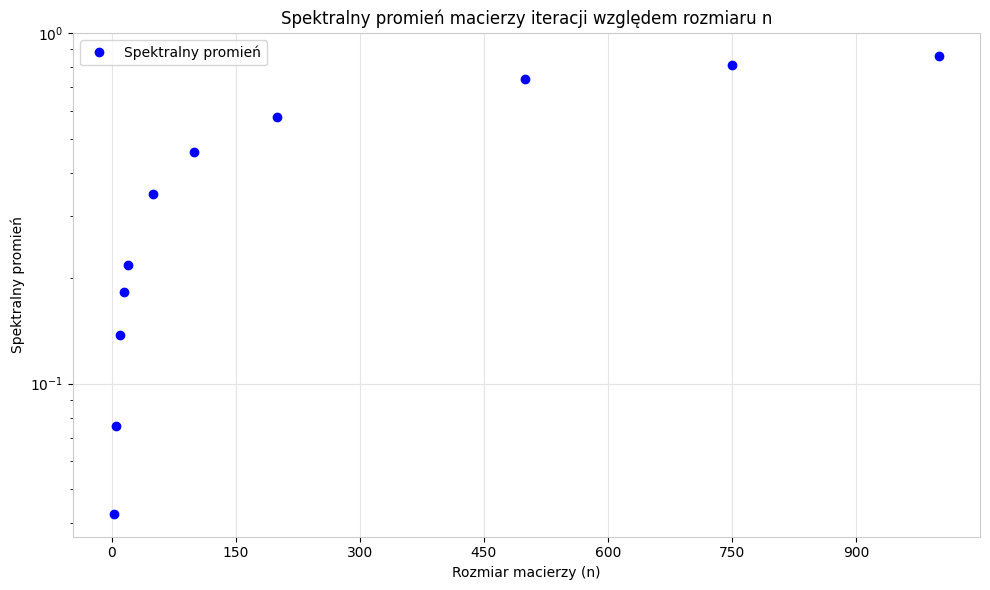

In [15]:
def plot_spectral_radius():
    data = pd.read_csv('data/spectral_radius_results.csv')

    plt.figure(figsize=(10, 6))
    plt.plot(data['n'], data['spectral_radius'], 'o', label='Spektralny promień', color='blue')
    plt.xlabel('Rozmiar macierzy (n)')
    plt.ylabel('Spektralny promień')
    plt.yscale('log')
    plt.title('Spektralny promień macierzy iteracji względem rozmiaru n')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    os.makedirs('plots', exist_ok=True)
    plt.savefig('plots/spectral_radius_plot.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_spectral_radius()